# SECTION 2: Huấn luyện ResNet50 cho GTSRB

Notebook này là bản hoàn chỉnh đã chỉnh theo tình trạng thực tế:

- Không copy dataset từ Google Drive sang `/content` nữa, vì bước copy quá lâu.
- Đọc trực tiếp `train.csv`, `val.csv`, `class_mapping.json` từ Section 1.
- Có `tqdm` để hiển thị tiến trình từng batch khi train/validation.
- Có `resume checkpoint` để tiếp tục train nếu bị ngắt sau một epoch.
- Lưu `resnet50_best.pth`, `resnet50_last.pth`, `history_resnet.csv/json`, `classification_report_resnet.txt`, `summary_resnet.json`.
- Dùng ResNet50 pretrained ImageNet, thay tầng `fc` cuối thành 43 lớp.


In [1]:
# ============================================================
# 1. Mount Google Drive
# ============================================================

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# ============================================================
# 2. Import thư viện
# ============================================================

import os
import json
import time
import copy
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

from torchvision import transforms, models

from sklearn.metrics import classification_report, accuracy_score

from tqdm.auto import tqdm


In [3]:
# ============================================================
# 3. Cấu hình chung
# ============================================================

BASE_DIR = "/content/drive/MyDrive/Deep_Learning"

DATA_DIR = os.path.join(BASE_DIR, "data")
SPLITS_DIR = os.path.join(DATA_DIR, "splits")

CHECKPOINT_DIR = os.path.join(BASE_DIR, "checkpoints")
HISTORY_DIR = os.path.join(BASE_DIR, "history")

os.makedirs(CHECKPOINT_DIR, exist_ok=True)
os.makedirs(HISTORY_DIR, exist_ok=True)

TRAIN_CSV = os.path.join(SPLITS_DIR, "train.csv")
VAL_CSV = os.path.join(SPLITS_DIR, "val.csv")
CLASS_MAPPING_PATH = os.path.join(SPLITS_DIR, "class_mapping.json")

RESNET_BEST_PATH = os.path.join(CHECKPOINT_DIR, "resnet50_best.pth")
RESNET_LAST_PATH = os.path.join(CHECKPOINT_DIR, "resnet50_last.pth")
RESNET_RESUME_PATH = os.path.join(CHECKPOINT_DIR, "resnet50_resume.pth")

HISTORY_JSON_PATH = os.path.join(HISTORY_DIR, "history_resnet.json")
HISTORY_CSV_PATH = os.path.join(HISTORY_DIR, "history_resnet.csv")
REPORT_TXT_PATH = os.path.join(HISTORY_DIR, "classification_report_resnet.txt")
SUMMARY_JSON_PATH = os.path.join(HISTORY_DIR, "summary_resnet.json")

SEED = 42
IMG_SIZE = 224
BATCH_SIZE = 32

NUM_WORKERS = 2

NUM_CLASSES = 43

EPOCHS = 15

LEARNING_RATE = 1e-3

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", device)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("Cảnh báo: Chưa có GPU. Vào Runtime → Change runtime type → GPU.")

print("TRAIN_CSV:", TRAIN_CSV)
print("VAL_CSV:", VAL_CSV)
print("CLASS_MAPPING_PATH:", CLASS_MAPPING_PATH)
print("CHECKPOINT_DIR:", CHECKPOINT_DIR)
print("HISTORY_DIR:", HISTORY_DIR)


Device: cuda
GPU: Tesla T4
TRAIN_CSV: /content/drive/MyDrive/Deep_Learning/data/splits/train.csv
VAL_CSV: /content/drive/MyDrive/Deep_Learning/data/splits/val.csv
CLASS_MAPPING_PATH: /content/drive/MyDrive/Deep_Learning/data/splits/class_mapping.json
CHECKPOINT_DIR: /content/drive/MyDrive/Deep_Learning/checkpoints
HISTORY_DIR: /content/drive/MyDrive/Deep_Learning/history


In [4]:
# ============================================================
# 4. Kiểm tra file đầu vào từ Section 1
# ============================================================

required_files = [TRAIN_CSV, VAL_CSV, CLASS_MAPPING_PATH]

for file_path in required_files:
    if not os.path.exists(file_path):
        raise FileNotFoundError(f"Không tìm thấy file: {file_path}")

train_df = pd.read_csv(TRAIN_CSV)
val_df = pd.read_csv(VAL_CSV)

with open(CLASS_MAPPING_PATH, "r", encoding="utf-8") as f:
    class_mapping = json.load(f)

print("Train shape:", train_df.shape)
print("Val shape:", val_df.shape)
print("Train columns:", train_df.columns.tolist())
print("Val columns:", val_df.columns.tolist())
print("Số class trong train:", train_df["label"].nunique())
print("Số class trong val:", val_df["label"].nunique())

display(train_df.head())


Train shape: (31367, 2)
Val shape: (7842, 2)
Train columns: ['path', 'label']
Val columns: ['path', 'label']
Số class trong train: 43
Số class trong val: 43


,path,label
0,/content/drive/MyDrive/Deep_Learning/data/extr...,12
1,/content/drive/MyDrive/Deep_Learning/data/extr...,5
2,/content/drive/MyDrive/Deep_Learning/data/extr...,12
3,/content/drive/MyDrive/Deep_Learning/data/extr...,13
4,/content/drive/MyDrive/Deep_Learning/data/extr...,18


In [5]:
# ============================================================
# 5. Xác định cột path và kiểm tra dữ liệu
# ============================================================

def get_path_column(df):
    if "path" in df.columns:
        return "path"
    if "image_path" in df.columns:
        return "image_path"
    raise ValueError("CSV phải có cột 'path' hoặc 'image_path'.")


PATH_COL = get_path_column(train_df)

print("Cột đường dẫn ảnh:", PATH_COL)

sample_path = train_df.iloc[0][PATH_COL]
print("Ảnh mẫu:", sample_path)
print("Tồn tại:", os.path.exists(sample_path))

if not os.path.exists(sample_path):
    raise FileNotFoundError(
        "Đường dẫn ảnh trong CSV không tồn tại. "
        "Hãy kiểm tra lại train.csv/val.csv từ Section 1."
    )


Cột đường dẫn ảnh: path
Ảnh mẫu: /content/drive/MyDrive/Deep_Learning/data/extracted/Train/12/00012_00031_00018.png
Tồn tại: True


In [6]:
# ============================================================
# 6. Copy GTSRB.zip sang /content rồi giải nén local
# ============================================================
# Cách này nhanh và ổn định hơn đọc hàng chục nghìn ảnh nhỏ trực tiếp từ Google Drive.

import zipfile
import shutil
import os
import time
from pathlib import Path

# Ưu tiên tìm file zip ở các vị trí phổ biến
possible_zip_paths = [
    "/content/drive/MyDrive/Deep_Learning/data/raw/GTSRB.zip",
    "/content/drive/MyDrive/Deep_Learning/data/raw/gtsrb.zip",
    "/content/drive/MyDrive/Deep_Learning/GTSRB.zip",
    "/content/drive/MyDrive/Deep_Learning/gtsrb.zip",
    "/content/drive/MyDrive/GTSRB.zip",
    "/content/drive/MyDrive/gtsrb.zip"
]

ZIP_PATH = None

for p in possible_zip_paths:
    if os.path.exists(p):
        ZIP_PATH = p
        break

if ZIP_PATH is None:
    raise FileNotFoundError(
        "Không tìm thấy GTSRB.zip trong Drive. "
        "Nên đặt file zip tại: /content/drive/MyDrive/Deep_Learning/data/raw/GTSRB.zip"
    )

LOCAL_ZIP_PATH = "/content/GTSRB.zip"
LOCAL_EXTRACTED_DIR = "/content/gtsrb_extracted"

print("Tìm thấy zip:", ZIP_PATH)

# Copy zip sang /content
if not os.path.exists(LOCAL_ZIP_PATH):
    print("Đang copy file zip sang /content...")
    start = time.time()
    shutil.copy2(ZIP_PATH, LOCAL_ZIP_PATH)
    print(f"Copy zip xong sau {time.time() - start:.2f} giây.")
else:
    print("File zip local đã tồn tại:", LOCAL_ZIP_PATH)

# Giải nén local
if not os.path.exists(LOCAL_EXTRACTED_DIR):
    print("Đang giải nén zip trong /content...")
    start = time.time()

    with zipfile.ZipFile(LOCAL_ZIP_PATH, "r") as zip_ref:
        zip_ref.extractall(LOCAL_EXTRACTED_DIR)

    print(f"Giải nén xong sau {time.time() - start:.2f} giây.")
else:
    print("Dataset local đã tồn tại:", LOCAL_EXTRACTED_DIR)

# Tạo CSV local bằng cách thay prefix Drive sang prefix local
DRIVE_EXTRACTED_DIR = "/content/drive/MyDrive/Deep_Learning/data/extracted"

train_df_local = train_df.copy()
val_df_local = val_df.copy()

train_df_local[PATH_COL] = train_df_local[PATH_COL].str.replace(
    DRIVE_EXTRACTED_DIR,
    LOCAL_EXTRACTED_DIR,
    regex=False
)

val_df_local[PATH_COL] = val_df_local[PATH_COL].str.replace(
    DRIVE_EXTRACTED_DIR,
    LOCAL_EXTRACTED_DIR,
    regex=False
)

LOCAL_TRAIN_CSV = "/content/train_local.csv"
LOCAL_VAL_CSV = "/content/val_local.csv"

train_df_local.to_csv(LOCAL_TRAIN_CSV, index=False)
val_df_local.to_csv(LOCAL_VAL_CSV, index=False)

print("LOCAL_TRAIN_CSV:", LOCAL_TRAIN_CSV)
print("LOCAL_VAL_CSV:", LOCAL_VAL_CSV)

# Kiểm tra ảnh local đầu tiên
local_sample_path = train_df_local.iloc[0][PATH_COL]
print("Ảnh local mẫu:", local_sample_path)
print("Tồn tại:", os.path.exists(local_sample_path))

if not os.path.exists(local_sample_path):
    raise FileNotFoundError(
        "Ảnh local không tồn tại sau khi thay path. "
        "Có thể cấu trúc giải nén trong zip khác với data/extracted hiện tại."
    )


Tìm thấy zip: /content/drive/MyDrive/Deep_Learning/data/raw/gtsrb.zip
Đang copy file zip sang /content...
Copy zip xong sau 16.68 giây.
Đang giải nén zip trong /content...
Giải nén xong sau 14.99 giây.
LOCAL_TRAIN_CSV: /content/train_local.csv
LOCAL_VAL_CSV: /content/val_local.csv
Ảnh local mẫu: /content/gtsrb_extracted/Train/12/00012_00031_00018.png
Tồn tại: True


In [7]:
# ============================================================
# 7. Transform cho ResNet50
# ============================================================
# Đồng bộ với Section 1:
# - Resize 224x224
# - Train có RandomRotation và ColorJitter
# - Normalize theo ImageNet

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomRotation(15),
    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2
    ),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

val_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])


In [8]:
# ============================================================
# 8. Dataset đọc ảnh từ CSV
# ============================================================

class GTSRBCSVDataset(Dataset):
    def __init__(self, csv_path, transform=None):
        self.data = pd.read_csv(csv_path)
        self.transform = transform

        if "path" in self.data.columns:
            self.path_col = "path"
        elif "image_path" in self.data.columns:
            self.path_col = "image_path"
        else:
            raise ValueError("CSV phải có cột 'path' hoặc 'image_path'.")

        if "label" not in self.data.columns:
            raise ValueError("CSV phải có cột 'label'.")

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        img_path = self.data.iloc[idx][self.path_col]
        label = int(self.data.iloc[idx]["label"])

        image = Image.open(img_path).convert("RGB")

        if self.transform is not None:
            image = self.transform(image)

        return image, label


In [9]:
# ============================================================
# 9. Tạo Dataset và DataLoader
# ============================================================

train_set = GTSRBCSVDataset(LOCAL_TRAIN_CSV, transform=train_transform)
val_set = GTSRBCSVDataset(LOCAL_VAL_CSV, transform=val_transform)

# Khi NUM_WORKERS = 0 thì không được bật persistent_workers.
persistent_workers_flag = NUM_WORKERS > 0

train_loader = DataLoader(
    train_set,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
    persistent_workers=persistent_workers_flag
)

val_loader = DataLoader(
    val_set,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
    persistent_workers=persistent_workers_flag
)

dataset_sizes = {
    "train": len(train_set),
    "val": len(val_set)
}

print("Tổng số ảnh Train:", dataset_sizes["train"])
print("Tổng số ảnh Val:", dataset_sizes["val"])
print("Số lượng Class:", NUM_CLASSES)

# Test thời gian load 1 batch
start = time.time()
batch_images, batch_labels = next(iter(train_loader))
print("Thời gian load 1 batch:", time.time() - start, "giây")
print("Batch image shape:", batch_images.shape)
print("Batch label shape:", batch_labels.shape)


Tổng số ảnh Train: 31367
Tổng số ảnh Val: 7842
Số lượng Class: 43
Thời gian load 1 batch: 0.8662796020507812 giây
Batch image shape: torch.Size([32, 3, 224, 224])
Batch label shape: torch.Size([32])


In [10]:
# ============================================================
# 10. Khởi tạo ResNet50 pretrained ImageNet
# ============================================================

model_resnet = models.resnet50(
    weights=models.ResNet50_Weights.DEFAULT
)

# Freeze backbone để train nhanh và ổn định.
# Chỉ train tầng fc mới.
for param in model_resnet.parameters():
    param.requires_grad = False

num_features = model_resnet.fc.in_features
model_resnet.fc = nn.Linear(num_features, NUM_CLASSES)

model_resnet = model_resnet.to(device)

print(model_resnet.fc)

trainable_params = sum(p.numel() for p in model_resnet.parameters() if p.requires_grad)
total_params = sum(p.numel() for p in model_resnet.parameters())

print("Trainable params:", trainable_params)
print("Total params:", total_params)


Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:01<00:00, 95.7MB/s]


Linear(in_features=2048, out_features=43, bias=True)
Trainable params: 88107
Total params: 23596139


In [11]:
# ============================================================
# 11. Loss function, Optimizer và AMP scaler
# ============================================================

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model_resnet.fc.parameters(),
    lr=LEARNING_RATE
)

# Mixed precision giúp train nhanh hơn trên GPU T4.
use_amp = torch.cuda.is_available()
scaler = torch.amp.GradScaler("cuda", enabled=use_amp)

print("Loss function:", criterion)
print("Optimizer:", optimizer)
print("Use AMP:", use_amp)


Loss function: CrossEntropyLoss()
Optimizer: Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0
)
Use AMP: True


In [12]:
# ============================================================
# 12. Hàm train và validation có tqdm
# ============================================================

def train_one_epoch(model, dataloader, criterion, optimizer, device, scaler=None, use_amp=False, epoch=None):
    model.train()

    running_loss = 0.0
    running_corrects = 0
    total_samples = 0

    progress_bar = tqdm(
        dataloader,
        desc=f"Train epoch {epoch}" if epoch is not None else "Training",
        leave=True
    )

    for images, labels in progress_bar:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        with torch.amp.autocast("cuda", enabled=use_amp):
            outputs = model(images)
            loss = criterion(outputs, labels)

        _, preds = torch.max(outputs, 1)

        if scaler is not None and use_amp:
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
        else:
            loss.backward()
            optimizer.step()

        batch_size = images.size(0)
        running_loss += loss.item() * batch_size
        running_corrects += torch.sum(preds == labels).item()
        total_samples += batch_size

        current_loss = running_loss / total_samples
        current_acc = running_corrects / total_samples

        progress_bar.set_postfix({
            "loss": f"{current_loss:.4f}",
            "acc": f"{current_acc:.4f}"
        })

    epoch_loss = running_loss / total_samples
    epoch_acc = running_corrects / total_samples

    return epoch_loss, epoch_acc


def validate_one_epoch(model, dataloader, criterion, device, use_amp=False, epoch=None):
    model.eval()

    running_loss = 0.0
    running_corrects = 0
    total_samples = 0

    all_labels = []
    all_preds = []

    progress_bar = tqdm(
        dataloader,
        desc=f"Val epoch {epoch}" if epoch is not None else "Validation",
        leave=True
    )

    with torch.no_grad():
        for images, labels in progress_bar:
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            with torch.amp.autocast("cuda", enabled=use_amp):
                outputs = model(images)
                loss = criterion(outputs, labels)

            _, preds = torch.max(outputs, 1)

            batch_size = images.size(0)
            running_loss += loss.item() * batch_size
            running_corrects += torch.sum(preds == labels).item()
            total_samples += batch_size

            all_labels.extend(labels.cpu().numpy())
            all_preds.extend(preds.cpu().numpy())

            current_loss = running_loss / total_samples
            current_acc = running_corrects / total_samples

            progress_bar.set_postfix({
                "loss": f"{current_loss:.4f}",
                "acc": f"{current_acc:.4f}"
            })

    epoch_loss = running_loss / total_samples
    epoch_acc = running_corrects / total_samples

    return epoch_loss, epoch_acc, all_labels, all_preds


In [13]:
# ============================================================
# 13. Resume checkpoint nếu có
# ============================================================

history_resnet = {
    "epoch": [],
    "train_loss": [],
    "train_acc": [],
    "val_loss": [],
    "val_acc": [],
    "epoch_time_sec": []
}

start_epoch = 1
best_val_acc = 0.0
best_epoch = 0
best_model_wts = copy.deepcopy(model_resnet.state_dict())

if os.path.exists(RESNET_RESUME_PATH):
    print("Tìm thấy resume checkpoint:", RESNET_RESUME_PATH)
    checkpoint = torch.load(RESNET_RESUME_PATH, map_location=device)

    model_resnet.load_state_dict(checkpoint["model_state_dict"])
    optimizer.load_state_dict(checkpoint["optimizer_state_dict"])

    start_epoch = checkpoint["epoch"] + 1
    best_val_acc = checkpoint.get("best_val_acc", 0.0)
    best_epoch = checkpoint.get("best_epoch", 0)
    history_resnet = checkpoint.get("history_resnet", history_resnet)

    best_model_wts = copy.deepcopy(model_resnet.state_dict())

    print(f"Tiếp tục train từ epoch {start_epoch}.")
    print(f"Best epoch hiện tại: {best_epoch}")
    print(f"Best val acc hiện tại: {best_val_acc:.4f}")
else:
    print("Không có resume checkpoint, train từ đầu.")


Tìm thấy resume checkpoint: /content/drive/MyDrive/Deep_Learning/checkpoints/resnet50_resume.pth
Tiếp tục train từ epoch 16.
Best epoch hiện tại: 12
Best val acc hiện tại: 0.8646


In [14]:
# ============================================================
# 14. Vòng lặp huấn luyện ResNet50
# ============================================================
# Có in tiến trình từng batch.
# Có lưu resume checkpoint và history sau mỗi epoch.

if start_epoch > EPOCHS:
    print(
        f"Checkpoint hiện tại đã train đến epoch {start_epoch - 1}, "
        f"lớn hơn hoặc bằng EPOCHS={EPOCHS}. Nếu muốn train tiếp, hãy tăng EPOCHS."
    )
else:
    start_training_time = time.time()

    for epoch in range(start_epoch, EPOCHS + 1):
        epoch_start_time = time.time()

        train_loss, train_acc = train_one_epoch(
            model_resnet,
            train_loader,
            criterion,
            optimizer,
            device,
            scaler=scaler,
            use_amp=use_amp,
            epoch=epoch
        )

        val_loss, val_acc, val_true, val_pred = validate_one_epoch(
            model_resnet,
            val_loader,
            criterion,
            device,
            use_amp=use_amp,
            epoch=epoch
        )

        epoch_time = time.time() - epoch_start_time

        history_resnet["epoch"].append(epoch)
        history_resnet["train_loss"].append(float(train_loss))
        history_resnet["train_acc"].append(float(train_acc))
        history_resnet["val_loss"].append(float(val_loss))
        history_resnet["val_acc"].append(float(val_acc))
        history_resnet["epoch_time_sec"].append(float(epoch_time))

        print(
            f"Epoch [{epoch}/{EPOCHS}] "
            f"| Train Loss: {train_loss:.4f} "
            f"| Train Acc: {train_acc:.4f} "
            f"| Val Loss: {val_loss:.4f} "
            f"| Val Acc: {val_acc:.4f} "
            f"| Time: {epoch_time:.2f}s"
        )

        # Cập nhật best model
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_epoch = epoch
            best_model_wts = copy.deepcopy(model_resnet.state_dict())

            torch.save({
                "model_name": "resnet50",
                "epoch": epoch,
                "model_state_dict": model_resnet.state_dict(),
                "optimizer_state_dict": optimizer.state_dict(),
                "best_val_acc": best_val_acc,
                "num_classes": NUM_CLASSES,
                "class_mapping": class_mapping,
                "image_size": IMG_SIZE,
                "path_col": PATH_COL
            }, RESNET_BEST_PATH)

            print(f"Đã lưu best checkpoint tại epoch {epoch}: {RESNET_BEST_PATH}")

        # Lưu resume checkpoint sau mỗi epoch
        torch.save({
            "model_name": "resnet50",
            "epoch": epoch,
            "model_state_dict": model_resnet.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "best_val_acc": best_val_acc,
            "best_epoch": best_epoch,
            "history_resnet": history_resnet,
            "num_classes": NUM_CLASSES,
            "class_mapping": class_mapping,
            "image_size": IMG_SIZE,
            "path_col": PATH_COL
        }, RESNET_RESUME_PATH)

        # Lưu history sau mỗi epoch
        history_df = pd.DataFrame(history_resnet)
        history_df.to_csv(HISTORY_CSV_PATH, index=False)

        with open(HISTORY_JSON_PATH, "w", encoding="utf-8") as f:
            json.dump(history_resnet, f, ensure_ascii=False, indent=4)

        print("Đã lưu resume checkpoint và history sau epoch", epoch)

    total_training_time = time.time() - start_training_time

    # Lưu last checkpoint sau khi hoàn tất
    torch.save({
        "model_name": "resnet50",
        "epoch": EPOCHS,
        "model_state_dict": model_resnet.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "last_val_acc": val_acc,
        "best_val_acc": best_val_acc,
        "best_epoch": best_epoch,
        "history_resnet": history_resnet,
        "num_classes": NUM_CLASSES,
        "class_mapping": class_mapping,
        "image_size": IMG_SIZE,
        "path_col": PATH_COL
    }, RESNET_LAST_PATH)

    # Load lại trọng số tốt nhất vào model hiện tại
    model_resnet.load_state_dict(best_model_wts)

    print("\nHuấn luyện hoàn tất.")
    print("Best epoch:", best_epoch)
    print("Best validation accuracy:", best_val_acc)
    print("Tổng thời gian huấn luyện phiên hiện tại:", f"{total_training_time:.2f}s")
    print("Best checkpoint:", RESNET_BEST_PATH)
    print("Resume checkpoint:", RESNET_RESUME_PATH)
    print("Last checkpoint:", RESNET_LAST_PATH)


Checkpoint hiện tại đã train đến epoch 15, lớn hơn hoặc bằng EPOCHS=15. Nếu muốn train tiếp, hãy tăng EPOCHS.


In [15]:
# ============================================================
# 15. Đọc và hiển thị history
# ============================================================

if os.path.exists(HISTORY_CSV_PATH):
    history_df = pd.read_csv(HISTORY_CSV_PATH)
else:
    history_df = pd.DataFrame(history_resnet)

display(history_df)


,epoch,train_loss,train_acc,val_loss,val_acc,epoch_time_sec
0,1,1.711973,0.564128,1.141797,0.711553,148.807205
1,2,0.978206,0.736220,0.883994,0.775822,145.432719
2,3,0.780276,0.787260,0.717519,0.803239,146.097445
3,4,0.670524,0.812956,0.652648,0.818286,143.470391
4,5,0.607255,0.824688,0.569056,0.842515,144.968559
5,6,0.558783,0.838907,0.533817,0.842260,143.238104
6,7,0.520264,0.845060,0.489081,0.854501,143.250212
7,8,0.491630,0.852807,0.496021,0.852971,143.242771
8,9,0.468872,0.858482,0.463907,0.857052,140.722703
9,10,0.450439,0.863933,0.442425,0.863173,144.351589


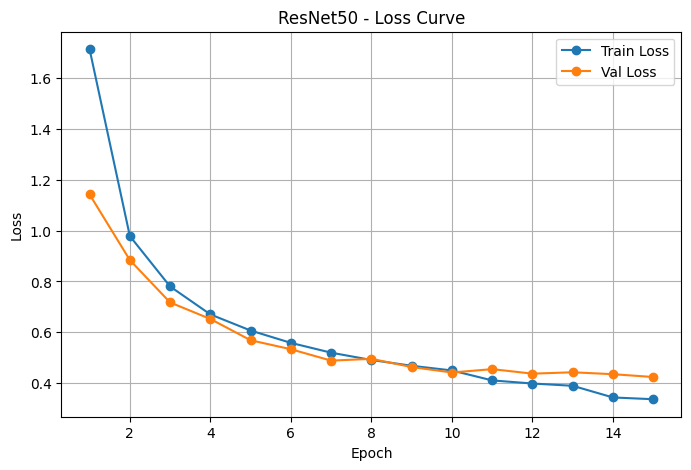

In [16]:
# ============================================================
# 16. Vẽ Loss Curve
# ============================================================

plt.figure(figsize=(8, 5))
plt.plot(history_df["epoch"], history_df["train_loss"], marker="o", label="Train Loss")
plt.plot(history_df["epoch"], history_df["val_loss"], marker="o", label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("ResNet50 - Loss Curve")
plt.legend()
plt.grid(True)
plt.show()


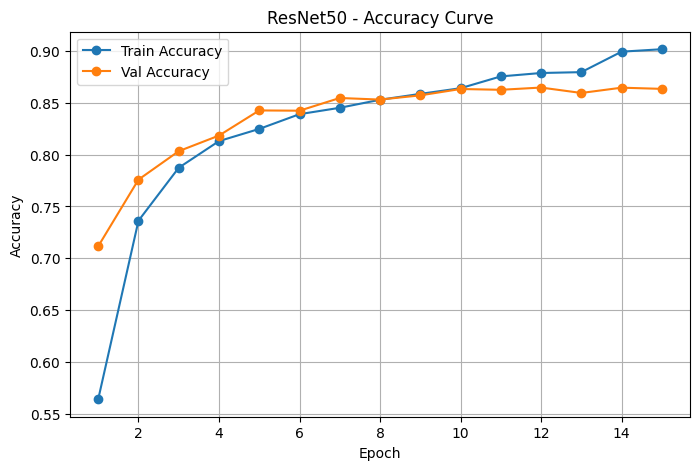

In [17]:
# ============================================================
# 17. Vẽ Accuracy Curve
# ============================================================

plt.figure(figsize=(8, 5))
plt.plot(history_df["epoch"], history_df["train_acc"], marker="o", label="Train Accuracy")
plt.plot(history_df["epoch"], history_df["val_acc"], marker="o", label="Val Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("ResNet50 - Accuracy Curve")
plt.legend()
plt.grid(True)
plt.show()


In [18]:
# ============================================================
# 18. Load best checkpoint và đánh giá lại trên validation
# ============================================================

if os.path.exists(RESNET_BEST_PATH):
    best_checkpoint = torch.load(RESNET_BEST_PATH, map_location=device)
    model_resnet.load_state_dict(best_checkpoint["model_state_dict"])
    print("Đã load best checkpoint:", RESNET_BEST_PATH)
    print("Best checkpoint epoch:", best_checkpoint.get("epoch"))
    print("Best checkpoint val acc:", best_checkpoint.get("best_val_acc"))
else:
    print("Không tìm thấy best checkpoint, dùng model hiện tại.")

val_loss, val_acc, y_true, y_pred = validate_one_epoch(
    model_resnet,
    val_loader,
    criterion,
    device,
    use_amp=use_amp,
    epoch="best"
)

print("Validation Loss:", val_loss)
print("Validation Accuracy:", val_acc)
print("Accuracy check:", accuracy_score(y_true, y_pred))


Đã load best checkpoint: /content/drive/MyDrive/Deep_Learning/checkpoints/resnet50_best.pth
Best checkpoint epoch: 12
Best checkpoint val acc: 0.864575363427697


Val epoch best:   0%|          | 0/246 [00:00<?, ?it/s]

Validation Loss: 0.4379002073382091
Validation Accuracy: 0.864575363427697
Accuracy check: 0.864575363427697


In [19]:
# ============================================================
# 19. Classification Report
# ============================================================

target_names = [
    str(class_mapping.get(str(i), f"Class {i}"))
    for i in range(NUM_CLASSES)
]

report_text = classification_report(
    y_true,
    y_pred,
    labels=list(range(NUM_CLASSES)),
    target_names=target_names,
    digits=4,
    zero_division=0
)

print(report_text)

with open(REPORT_TXT_PATH, "w", encoding="utf-8") as f:
    f.write(report_text)

print("Đã lưu classification_report:", REPORT_TXT_PATH)


              precision    recall  f1-score   support

       00000     0.7750    0.7381    0.7561        42
       00001     0.8525    0.6509    0.7382       444
       00002     0.6628    0.7689    0.7119       450
       00003     0.8017    0.6596    0.7237       282
       00004     0.7372    0.8005    0.7676       396
       00005     0.7448    0.7769    0.7605       372
       00006     0.9873    0.9286    0.9571        84
       00007     0.7011    0.8715    0.7771       288
       00008     0.8144    0.7624    0.7875       282
       00009     0.8911    0.9184    0.9045       294
       00010     0.9136    0.9204    0.9170       402
       00011     0.9077    0.8939    0.9008       264
       00012     0.9929    0.9976    0.9952       420
       00013     0.9816    0.9884    0.9850       432
       00014     1.0000    1.0000    1.0000       156
       00015     0.9841    0.9841    0.9841       126
       00016     0.9753    0.9405    0.9576        84
       00017     0.9823    

In [20]:
# ============================================================
# 20. Tóm tắt kết quả phục vụ so sánh với ViT
# ============================================================

model_size_mb = os.path.getsize(RESNET_BEST_PATH) / (1024 * 1024) if os.path.exists(RESNET_BEST_PATH) else None
avg_epoch_time = float(np.mean(history_df["epoch_time_sec"])) if len(history_df) > 0 else None

resnet_summary = {
    "model": "ResNet50",
    "epochs": int(EPOCHS),
    "best_epoch": int(best_epoch),
    "best_val_acc": float(best_val_acc),
    "final_val_loss": float(val_loss),
    "final_val_acc": float(val_acc),
    "avg_epoch_time_sec": avg_epoch_time,
    "best_checkpoint_size_mb": float(model_size_mb) if model_size_mb is not None else None,
    "best_checkpoint_path": RESNET_BEST_PATH,
    "resume_checkpoint_path": RESNET_RESUME_PATH,
    "history_csv_path": HISTORY_CSV_PATH,
    "classification_report_path": REPORT_TXT_PATH
}

with open(SUMMARY_JSON_PATH, "w", encoding="utf-8") as f:
    json.dump(resnet_summary, f, ensure_ascii=False, indent=4)

print("===== RESNET50 SUMMARY =====")
for key, value in resnet_summary.items():
    print(f"{key}: {value}")

print("\nĐã lưu summary:", SUMMARY_JSON_PATH)


===== RESNET50 SUMMARY =====
model: ResNet50
epochs: 15
best_epoch: 12
best_val_acc: 0.864575363427697
final_val_loss: 0.4379002073382091
final_val_acc: 0.864575363427697
avg_epoch_time_sec: 144.36645007133484
best_checkpoint_size_mb: 90.99267101287842
best_checkpoint_path: /content/drive/MyDrive/Deep_Learning/checkpoints/resnet50_best.pth
resume_checkpoint_path: /content/drive/MyDrive/Deep_Learning/checkpoints/resnet50_resume.pth
history_csv_path: /content/drive/MyDrive/Deep_Learning/history/history_resnet.csv
classification_report_path: /content/drive/MyDrive/Deep_Learning/history/classification_report_resnet.txt

Đã lưu summary: /content/drive/MyDrive/Deep_Learning/history/summary_resnet.json


In [21]:
# ============================================================
# Lưu cấu hình thí nghiệm ResNet50
# ============================================================

CONFIG_DIR = os.path.join(BASE_DIR, "configs")
os.makedirs(CONFIG_DIR, exist_ok=True)

RESNET_CONFIG_PATH = os.path.join(CONFIG_DIR, "resnet50_config.json")

resnet50_config = {
    "section": "Section 2",
    "model_name": "ResNet50",
    "task": "GTSRB Traffic Sign Classification",
    "num_classes": NUM_CLASSES,

    "base_dir": BASE_DIR,
    "train_csv": TRAIN_CSV,
    "val_csv": VAL_CSV,
    "class_mapping_path": CLASS_MAPPING_PATH,

    "image_size": IMG_SIZE,
    "batch_size": BATCH_SIZE,
    "num_workers": NUM_WORKERS,
    "epochs": EPOCHS,
    "learning_rate": LEARNING_RATE,
    "optimizer": "Adam",
    "loss_function": "CrossEntropyLoss",

    "pretrained_weights": "ResNet50_Weights.DEFAULT",
    "transfer_learning": True,
    "freeze_backbone": True,
    "trainable_layer": "fc",

    "train_transform": {
        "Resize": [IMG_SIZE, IMG_SIZE],
        "RandomRotation": 15,
        "ColorJitter": {
            "brightness": 0.2,
            "contrast": 0.2
        },
        "Normalize": {
            "mean": [0.485, 0.456, 0.406],
            "std": [0.229, 0.224, 0.225]
        }
    },

    "val_transform": {
        "Resize": [IMG_SIZE, IMG_SIZE],
        "Normalize": {
            "mean": [0.485, 0.456, 0.406],
            "std": [0.229, 0.224, 0.225]
        }
    },

    "checkpoint_paths": {
        "best": RESNET_BEST_PATH,
        "last": RESNET_LAST_PATH,
        "resume": RESNET_RESUME_PATH
    },

    "history_paths": {
        "history_csv": HISTORY_CSV_PATH,
        "history_json": HISTORY_JSON_PATH,
        "classification_report": REPORT_TXT_PATH,
        "summary": SUMMARY_JSON_PATH
    },

    "device": str(device),
    "seed": SEED
}

with open(RESNET_CONFIG_PATH, "w", encoding="utf-8") as f:
    json.dump(resnet50_config, f, ensure_ascii=False, indent=4)

print("Đã lưu ResNet50 config tại:", RESNET_CONFIG_PATH)

Đã lưu ResNet50 config tại: /content/drive/MyDrive/Deep_Learning/configs/resnet50_config.json


In [22]:
import pandas as pd
import json
import os

BASE_DIR = "/content/drive/MyDrive/Deep_Learning"

history_path = os.path.join(BASE_DIR, "history", "history_resnet.csv")
summary_path = os.path.join(BASE_DIR, "history", "summary_resnet.json")
report_path = os.path.join(BASE_DIR, "history", "classification_report_resnet.txt")

history = pd.read_csv(history_path)
display(history)

with open(summary_path, "r", encoding="utf-8") as f:
    summary = json.load(f)

summary

,epoch,train_loss,train_acc,val_loss,val_acc,epoch_time_sec
0,1,1.711973,0.564128,1.141797,0.711553,148.807205
1,2,0.978206,0.736220,0.883994,0.775822,145.432719
2,3,0.780276,0.787260,0.717519,0.803239,146.097445
3,4,0.670524,0.812956,0.652648,0.818286,143.470391
4,5,0.607255,0.824688,0.569056,0.842515,144.968559
5,6,0.558783,0.838907,0.533817,0.842260,143.238104
6,7,0.520264,0.845060,0.489081,0.854501,143.250212
7,8,0.491630,0.852807,0.496021,0.852971,143.242771
8,9,0.468872,0.858482,0.463907,0.857052,140.722703
9,10,0.450439,0.863933,0.442425,0.863173,144.351589


{'model': 'ResNet50',
 'epochs': 15,
 'best_epoch': 12,
 'best_val_acc': 0.864575363427697,
 'final_val_loss': 0.4379002073382091,
 'final_val_acc': 0.864575363427697,
 'avg_epoch_time_sec': 144.36645007133484,
 'best_checkpoint_size_mb': 90.99267101287842,
 'best_checkpoint_path': '/content/drive/MyDrive/Deep_Learning/checkpoints/resnet50_best.pth',
 'resume_checkpoint_path': '/content/drive/MyDrive/Deep_Learning/checkpoints/resnet50_resume.pth',
 'history_csv_path': '/content/drive/MyDrive/Deep_Learning/history/history_resnet.csv',
 'classification_report_path': '/content/drive/MyDrive/Deep_Learning/history/classification_report_resnet.txt'}